# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



In [4]:
# !git clone https://github.com/soerenab/AudioMNIST.git

In [5]:
import os
import random
import torch
import torchaudio
import torchaudio.transforms as T
import librosa
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Subset
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from sklearn.manifold import TSNE
from pathlib import Path
from omegaconf import DictConfig
import warnings

warnings.filterwarnings('ignore')
# warnings.filterwarnings("ignore", module="torchaudio._backend")

plt.rcParams.update({'font.size': 14})

#Проверка CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Available device: {device}")

# #Установка seed для воспроизводимости
# def set_seed(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(seed)

# set_seed(42)

# Фиксация всех источников случайности
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

Available device: cuda


In [6]:
class LogMelSpectrogram(T.MelSpectrogram):
    """Логарифмический Mel-спектрограммный слой с эпсилон для численной стабильности"""
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

class AudioMNISTDataset(torch.utils.data.Dataset):
    """
    Датасет для загрузки аудио из AudioMNIST.
    Каждый файл имеет формат: digit_speaker_... .wav
    """
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self._list_wavs_and_labels(root)

    def _list_wavs_and_labels(self, root: str):
        base = Path(root)
        speakers = sorted([p for p in base.iterdir() if p.is_dir()])
        items = []
        for sp in speakers:
            for wav in sorted(sp.glob("**/*.wav")):
                name = wav.stem.split("_")
                digit = int(name[0])  # первая цифра в имени файла - это метка
                speaker_id = sp.name
                items.append((str(wav), digit, speaker_id))
        return items

    def __len__(self):
        return len(self.items)

    def _load_wav(self, path):
        
        y, sr = librosa.load(path, sr=None, mono=True)
        wav = torch.from_numpy(y).float().unsqueeze(0)

        # wav, sr = torchaudio.load(path)

        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # моно
        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self._load_wav(path)
        return wav, label

def collate_fn(batch):
    """Функция для паддинга аудио разной длины в батче"""
    wavs, labels = zip(*batch)
    # Паддинг до максимальной длины в батче
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels

def split_indices_by_speaker(dataset, test_speakers):
    """Разделение данных по спикерам (чтобы не было утечки между train и val)"""
    train_idxs, test_idxs = [], []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs

# Загрузка и разделение датасета
root = '../AudioMNIST/data'
full_ds = AudioMNISTDataset(root=root)

# Разделение по спикерам: последние 12 спикеров - валидация
NUM_TEST_SPEAKERS = 12
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)

train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(valid_ds)}")

Train samples: 24000
Validation samples: 6000


## Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

Возьмем из сема **модельку ResNet18** для 2D входов, те работаем со **спектрограммами**

In [ ]:
## Your code here
# Код из семинара - ResNet2D архитектура
class Block2D(nn.Module):
    """Базовый блок для ResNet2D"""
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(Block2D, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        return x

class ResNet2D(nn.Module):
    """ResNet18 для 2D входов (спектрограммы)"""
    def __init__(self, img_channels=1, num_classes=10):
        super(ResNet2D, self).__init__()
        layers = [2, 2, 2, 2]
        self.expansion = 1
        self.in_channels = 64

        self.conv1 = nn.Conv2d(img_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(Block2D, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(Block2D, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(Block2D, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(Block2D, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []
        if stride != 1:
            identity_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )
        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels * self.expansion
        for _ in range(1, num_residual_blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class SupervisedModel(nn.Module):
    """Supervised классификатор на основе спектрограмм"""
    def __init__(self, num_classes=10):
        super(SupervisedModel, self).__init__()
        self.encoder = ResNet2D(img_channels=1, num_classes=num_classes)

    def forward(self, spectrograms):
        return self.encoder(spectrograms)

def train_supervised(model, train_loader, val_loader, config):
    """Функция обучения supervised модели"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.EPOCHS)

    train_losses, val_accuracies = [], []

    for epoch in range(config.EPOCHS):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS}")

        for audio, labels in progress_bar:
            audio = audio.unsqueeze(1).to(device)  #[B, 1, T]
            labels = labels.to(device)

            #спектрограмма
            with torch.no_grad():
                mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048,
                                                  hop_length=128, n_mels=128).to(device)
                spectrograms = mel_transform(audio.squeeze(1))
                spectrograms = spectrograms.unsqueeze(1)  #[B, 1, n_mels, T]

            optimizer.zero_grad()
            outputs = model(spectrograms)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        scheduler.step()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_acc = evaluate_supervised(model, val_loader, config)
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch+1}: Train Loss = {avg_loss:.4f}, Val Accuracy = {val_acc:.4f}")

    return train_losses, val_accuracies

def evaluate_supervised(model, val_loader, config):
    """Оценка supervised модели"""
    model.eval()
    correct, total = 0, 0
    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128).to(device)

    with torch.no_grad():
        for audio, labels in val_loader:
            audio = audio.unsqueeze(1).to(device)
            labels = labels.to(device)
            spectrograms = mel_transform(audio.squeeze(1))
            spectrograms = spectrograms.unsqueeze(1)
            outputs = model(spectrograms)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

#конфиг
supervised_config = DictConfig({
    'LR': 1e-3,
    'WEIGHT_DECAY': 1e-4,
    'EPOCHS': 5,
    'BATCH_SIZE': 64
})

#данные сюда
train_loader = DataLoader(train_ds, batch_size=supervised_config.BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(valid_ds, batch_size=supervised_config.BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn)

#Обучаем (запускаем шарманку)
supervised_model = SupervisedModel(num_classes=10).to(device)
train_losses, val_accuracies = train_supervised(supervised_model, train_loader, val_loader, supervised_config)


Epoch 1/5:   0%|          | 0/375 [00:00<?, ?it/s]

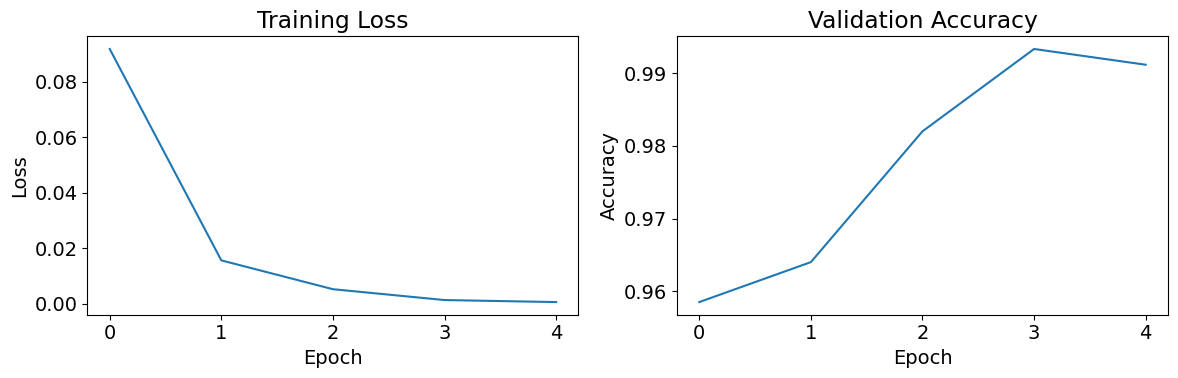

Best validation accuracy: 0.9933
Final validation accuracy: 0.9912


In [ ]:
#Посмотрим на графички-картиночки
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(val_accuracies)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(val_accuracies):.4f}")
print(f"Final validation accuracy: {val_accuracies[-1]:.4f}")

Видим что модель уже на 3 эпохе сошлась (если на лосс посмотрим) и лучшая акураси у нас **0.99,** пяти эпох для обучения хватило с головой, считаю результат - вау!

## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

Берем архитектуру энкодеров с сема (ResNet1D и ResNet2D_Encoder), проекционные headers и аугментации. Тут я немного добавила от себя (не по свой воле, просто без этого все ломалось) - заменила реализацию InfoNCE на CrossEntropyLoss, тк семинарский код мне давал переполнение при мелкой температуре и лосс улетал в nan + добавила gradient clipping для стабилизации обучения, чтоб скачков не было

In [ ]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

class Block1D(nn.Module):
    """Базовый блок для ResNet1D"""
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(Block1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        return x

class ResNet1D(nn.Module):
    """ResNet18 для 1D входов (raw waveform)"""
    def __init__(self):
        super(ResNet1D, self).__init__()
        layers = [2, 2, 2, 2]
        self.expansion = 1
        self.in_channels = 64

        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(Block1D, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(Block1D, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(Block1D, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(Block1D, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []
        if stride != 1:
            identity_downsample = nn.Sequential(
                nn.Conv1d(self.in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels * self.expansion)
            )
        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels * self.expansion
        for _ in range(1, num_residual_blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.squeeze(-1)
        return x

class Block2D(nn.Module):
    """Базовый блок для ResNet2D"""
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(Block2D, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        return x

class ResNet2D_Encoder(nn.Module):
    """ResNet18 для спектрограмм"""
    def __init__(self, img_channels=1):
        super(ResNet2D_Encoder, self).__init__()
        layers = [2, 2, 2, 2]
        self.expansion = 1
        self.in_channels = 64

        self.conv1 = nn.Conv2d(img_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(Block2D, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(Block2D, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(Block2D, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(Block2D, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []
        if stride != 1:
            identity_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )
        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels * self.expansion
        for _ in range(1, num_residual_blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return x

class ContrastiveNet(nn.Module):
    """Модель для контрастивного обучения с двумя энкодерами"""
    def __init__(self, projection_dim=128):
        super(ContrastiveNet, self).__init__()
        self.encoder_1d = ResNet1D()
        self.encoder_2d = ResNet2D_Encoder(img_channels=1)

        self.projection_head_1d = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )

        self.projection_head_2d = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )

    def forward(self, waveform, spectrogram):
        feat_1d = self.encoder_1d(waveform)  #[B, 512]
        feat_2d = self.encoder_2d(spectrogram)  #[B, 512]

        proj_1d = self.projection_head_1d(feat_1d)
        proj_2d = self.projection_head_2d(feat_2d)

        return proj_1d, proj_2d, feat_1d, feat_2d


class InfoNCELoss(nn.Module):
    """
    InfoNCE loss через CrossEntropyLoss
    """
    def __init__(self, temperature=0.5):
        super(InfoNCELoss, self).__init__()
        self.temperature = temperature
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]

        z_i = F.normalize(z_i, p=2, dim=1)
        z_j = F.normalize(z_j, p=2, dim=1)

        #Конкатенация:[z_i, z_j]размер [2B, D]
        z = torch.cat([z_i, z_j], dim=0)

        #Матрица сходства [2B, 2B]
        similarity = torch.matmul(z, z.T) / self.temperature

        similarity = torch.clamp(similarity, min=-50.0, max=50.0)

        labels = torch.cat([torch.arange(batch_size, 2 * batch_size),
                            torch.arange(batch_size)], dim=0).to(z.device)

        loss = self.cross_entropy(similarity, labels)

        return loss

#тут аугментации зафигачим
def fade_in_out(audio):
    """Fade in/out аугментация"""
    fade_shapes = ['linear', 'logarithmic', 'exponential']
    fade_size = random.randint(1, max(1, audio.shape[2] // 2))
    fade_shape = random.choice(fade_shapes)

    transform = T.Fade(fade_in_len=fade_size, fade_out_len=fade_size, fade_shape=fade_shape)
    return transform(audio)

def timemasking(waveform, mask_ratio=0.125):
    """Time masking аугментация"""
    bs, ch, length = waveform.shape
    mask_len = max(1, int(length * mask_ratio))
    augmented = waveform.clone()
    for i in range(bs):
        if length > mask_len:
            start = random.randint(0, length - mask_len)
            augmented[i, :, start:start + mask_len] = 0.0
    return augmented

def create_contrastive_input(audio, mel_transform, augmentation=True):
    """Создание входных данных для контрастивного обучения"""
    audio = audio.unsqueeze(1)  #[B, 1, T]

    if augmentation:
        try:
            audio = fade_in_out(audio)
            audio = timemasking(audio)
        except:
            pass

    with torch.no_grad():
        spectrograms = mel_transform(audio.squeeze(1))
        spectrograms = spectrograms.unsqueeze(1)
        spectrograms = torch.nan_to_num(spectrograms, nan=0.0, posinf=0.0, neginf=0.0)

    return spectrograms, audio

def train_contrastive(model, loss_fn, train_loader, val_loader, config):
    """Обучение контрастивной модели с выводом на каждой эпохе"""
    optimizer = optim.Adam(model.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.EPOCHS)
    mel_transform = LogMelSpectrogram(
        sample_rate=16000,
        n_fft=2048,
        hop_length=128,
        n_mels=128,
        f_min=40,
        f_max=8000
    ).to(device)

    train_losses = []
    val_accuracies = []

    for epoch in range(config.EPOCHS):
        model.train()
        epoch_loss = 0.0
        num_valid_batches = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS}")

        for batch_idx, (audio, _) in enumerate(progress_bar):
            audio = audio.to(device)
            spectrograms, waveforms = create_contrastive_input(audio, mel_transform, augmentation=True)

            optimizer.zero_grad()
            proj_1d, proj_2d, _, _ = model(waveforms, spectrograms)
            loss = loss_fn(proj_1d, proj_2d)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            num_valid_batches += 1
            progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()

        avg_loss = epoch_loss / max(1, num_valid_batches)
        train_losses.append(avg_loss)

        try:
            val_acc = evaluate_contrastive(model, val_loader, config, mel_transform)
            val_accuracies.append(val_acc)
            # Печатаем как в supervised задании
            print(f"Epoch {epoch+1}: Train Loss = {avg_loss:.4f}, Val Accuracy = {val_acc:.4f}")
        except Exception as e:
            val_accuracies.append(0.0)
            print(f"Epoch {epoch+1}: Train Loss = {avg_loss:.4f}, Val Accuracy = 0.0000")

    return train_losses, val_accuracies

def evaluate_contrastive(model, val_loader, config, mel_transform):
    """Оценка качества эмбеддингов через линейный классификатор"""
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for audio, labels in val_loader:
            audio = audio.to(device)
            spectrograms, waveforms = create_contrastive_input(audio, mel_transform, augmentation=False)
            _, _, feat_1d, feat_2d = model(waveforms, spectrograms)
            features = torch.cat([feat_1d, feat_2d], dim=1)
            all_features.append(features.cpu())
            all_labels.append(labels)

    features = torch.cat(all_features, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()

    features = np.nan_to_num(features, nan=0.0)

    X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42)

    clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
    clf.fit(X_train, y_train)
    accuracy = clf.score(X_val, y_val)

    return accuracy

#наш конфиг
contrastive_config = DictConfig({
    'LR': 1e-3,
    'WEIGHT_DECAY': 1e-4,
    'EPOCHS': 5,
    'BATCH_SIZE': 32,
    'PROJECTION_DIM': 128,
    'TEMPERATURE': 0.5
})


contrastive_model = ContrastiveNet(projection_dim=contrastive_config.PROJECTION_DIM).to(device)
loss_fn = InfoNCELoss(temperature=contrastive_config.TEMPERATURE)

train_loader = DataLoader(train_ds, batch_size=contrastive_config.BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn, drop_last=True)
val_loader = DataLoader(valid_ds, batch_size=contrastive_config.BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn)

#обучаем (дай бог запустится)
train_losses, val_accuracies = train_contrastive(
    contrastive_model, loss_fn, train_loader, val_loader, contrastive_config
)



Epoch 1/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1: Train Loss = 2.7028, Val Accuracy = 0.9450


Epoch 2/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 2: Train Loss = 2.5459, Val Accuracy = 0.9550


Epoch 3/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 3: Train Loss = 2.4943, Val Accuracy = 0.9650


Epoch 4/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 4: Train Loss = 2.4671, Val Accuracy = 0.9608


Epoch 5/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 5: Train Loss = 2.4499, Val Accuracy = 0.9617


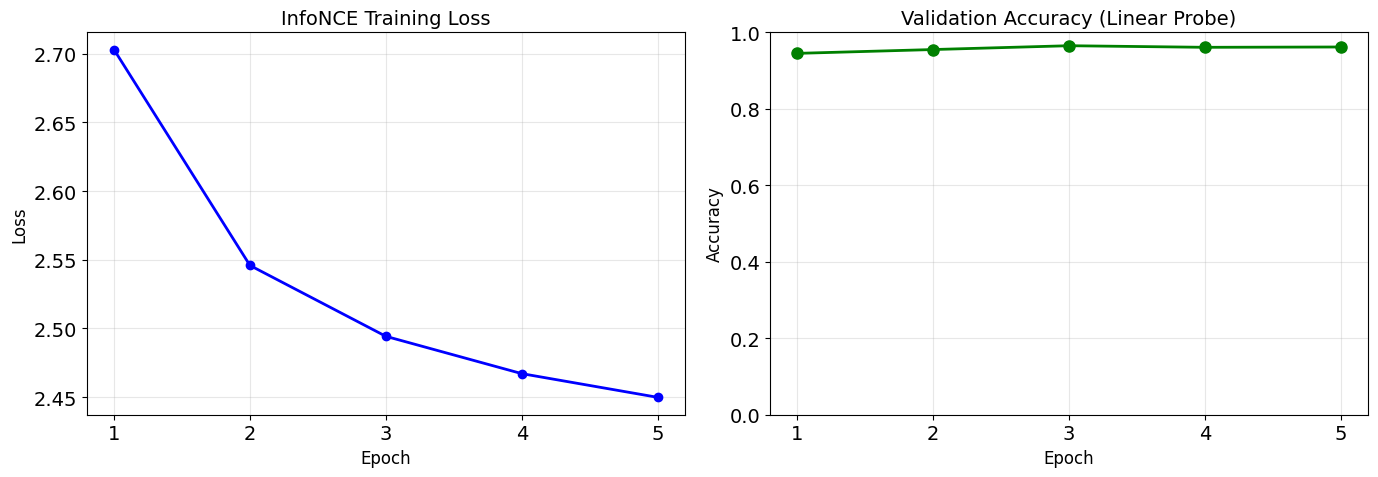

Best validation accuracy: 0.9650
Final validation accuracy: 0.9617
Final training loss: 2.4499


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#loss
axes[0].plot(train_losses, linewidth=2, color='blue', marker='o')
axes[0].set_title('InfoNCE Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(train_losses)))
axes[0].set_xticklabels(range(1, len(train_losses) + 1))

#accuracy
axes[1].plot(range(1, len(val_accuracies) + 1), val_accuracies,
             marker='o', linestyle='-', linewidth=2, color='green', markersize=8)
axes[1].set_title('Validation Accuracy (Linear Probe)', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)
axes[1].set_xticks(range(1, len(val_accuracies) + 1))

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(val_accuracies):.4f}")
print(f"Final validation accuracy: {val_accuracies[-1]:.4f}")
print(f"Final training loss: {train_losses[-1]:.4f}")

Видим что качество так-то классное, учитывая, что мы обучили модельку понимать аудио без меток. В целом логично, что акураси меньше, чем в supervised, но меня удивило, что оно прям достаточно высокое, крутяк!! Возможно больше эпох для обучения нужно (если смотреть на график лосса), хотя возможно в таком случае мы вообще переобучились бы

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


Ну я тут выпендриваться не буду, взяла BYOL (еле запустила, прости господи). Ну и если на логику опираться, что BYOL справляется с любым размером батча (в отличие от предыдущего например, где большие батчи нужны), что для нас хорошо. Также он не чувствителен к выбору температуры, а это именно то, что мне пришлось фиксить в прошлом задании, потому что базовые настройки у меня поломали весь лосс. Так что беру BYOL

In [ ]:
## Your code here
#BYOL берем

class BYOLModel(nn.Module):
    """
    BYOL модель
    """
    def __init__(self, projection_dim=256, hidden_dim=512, momentum=0.996):
        super(BYOLModel, self).__init__()
        self.momentum = momentum

        self.online_encoder_1d = ResNet1D()
        self.online_encoder_2d = ResNet2D_Encoder(img_channels=1)

        self.target_encoder_1d = ResNet1D()
        self.target_encoder_2d = ResNet2D_Encoder(img_channels=1)

        for param in self.target_encoder_1d.parameters():
            param.requires_grad = False
        for param in self.target_encoder_2d.parameters():
            param.requires_grad = False

        self.online_projector_1d = nn.Sequential(
            nn.Linear(512, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        self.online_projector_2d = nn.Sequential(
            nn.Linear(512, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        self.predictor_1d = nn.Sequential(
            nn.Linear(projection_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        self.predictor_2d = nn.Sequential(
            nn.Linear(projection_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        self.target_projector_1d = nn.Sequential(
            nn.Linear(512, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        self.target_projector_2d = nn.Sequential(
            nn.Linear(512, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        for param in self.target_projector_1d.parameters():
            param.requires_grad = False
        for param in self.target_projector_2d.parameters():
            param.requires_grad = False

        self._update_target_network(momentum=0)

    def _update_target_network(self, momentum=None):
        """Обновление целевой сети через скользящее среднее"""
        if momentum is None:
            momentum = self.momentum

        #обновим энкодеры
        for online_param, target_param in zip(self.online_encoder_1d.parameters(),
                                               self.target_encoder_1d.parameters()):
            target_param.data = momentum * target_param.data + (1 - momentum) * online_param.data

        for online_param, target_param in zip(self.online_encoder_2d.parameters(),
                                               self.target_encoder_2d.parameters()):
            target_param.data = momentum * target_param.data + (1 - momentum) * online_param.data

        #сейм, но проекторы
        for online_param, target_param in zip(self.online_projector_1d.parameters(),
                                               self.target_projector_1d.parameters()):
            target_param.data = momentum * target_param.data + (1 - momentum) * online_param.data

        for online_param, target_param in zip(self.online_projector_2d.parameters(),
                                               self.target_projector_2d.parameters()):
            target_param.data = momentum * target_param.data + (1 - momentum) * online_param.data

    def forward_online(self, waveform, spectrogram):
        """Прямой проход онлайн сети"""
        feat_1d = self.online_encoder_1d(waveform)
        feat_2d = self.online_encoder_2d(spectrogram)

        proj_1d = self.online_projector_1d(feat_1d)
        proj_2d = self.online_projector_2d(feat_2d)

        pred_1d = self.predictor_1d(proj_1d)
        pred_2d = self.predictor_2d(proj_2d)

        return pred_1d, pred_2d, feat_1d, feat_2d

    @torch.no_grad()
    def forward_target(self, waveform, spectrogram):
        """Прямой проход целевой сети (без градиентов)"""
        feat_1d = self.target_encoder_1d(waveform)
        feat_2d = self.target_encoder_2d(spectrogram)

        target_1d = self.target_projector_1d(feat_1d)
        target_2d = self.target_projector_2d(feat_2d)

        return target_1d, target_2d

    def forward(self, waveform, spectrogram):
        """Полный forward"""
        pred_1d, pred_2d, _, _ = self.forward_online(waveform, spectrogram)
        target_1d, target_2d = self.forward_target(waveform, spectrogram)
        return pred_1d, pred_2d, target_1d, target_2d


class BYOLLoss(nn.Module):
    """
    BYOL loss
    """
    def __init__(self):
        super(BYOLLoss, self).__init__()

    def forward(self, pred, target):
        pred = F.normalize(pred, p=2, dim=1)
        target = F.normalize(target, p=2, dim=1)
        loss = 2 - 2 * (pred * target).sum(dim=1)
        return loss.mean()


#аугментации сделаем тоже

def create_byol_input(audio, mel_transform, augmentation=True):
    """аугментации"""
    audio = audio.unsqueeze(1)

    if augmentation:
        try:
            audio1 = fade_in_out(audio.clone())
            audio1 = timemasking(audio1)
            audio2 = fade_in_out(audio.clone())
            audio2 = timemasking(audio2)
        except:
            audio1 = audio
            audio2 = audio
    else:
        audio1 = audio
        audio2 = audio

    with torch.no_grad():
        spec1 = mel_transform(audio1.squeeze(1))
        spec1 = spec1.unsqueeze(1)
        spec1 = torch.nan_to_num(spec1, nan=0.0, posinf=0.0, neginf=0.0)

        spec2 = mel_transform(audio2.squeeze(1))
        spec2 = spec2.unsqueeze(1)
        spec2 = torch.nan_to_num(spec2, nan=0.0, posinf=0.0, neginf=0.0)

    return (spec1, audio1), (spec2, audio2)

def train_byol(model, byol_loss, train_loader, val_loader, config):
    """Обучение BYOL модели"""
    optimizer = optim.Adam(model.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.EPOCHS)
    mel_transform = LogMelSpectrogram(
        sample_rate=16000,
        n_fft=2048,
        hop_length=128,
        n_mels=128,
        f_min=40,
        f_max=8000
    ).to(device)

    train_losses = []
    val_accuracies = []

    for epoch in range(config.EPOCHS):
        model.train()
        epoch_loss = 0.0
        num_valid_batches = 0
        progress_bar = tqdm(train_loader, desc=f"BYOL Epoch {epoch+1}/{config.EPOCHS}")

        for audio, _ in progress_bar:
            audio = audio.to(device)

            (spec1, wav1), (spec2, wav2) = create_byol_input(audio, mel_transform, augmentation=True)

            optimizer.zero_grad()
            pred_1d_1, pred_2d_1, target_1d_1, target_2d_1 = model.forward(wav1, spec1)
            pred_1d_2, pred_2d_2, target_1d_2, target_2d_2 = model.forward(wav2, spec2)
            loss_1 = byol_loss(pred_1d_1, target_1d_2)
            loss_2 = byol_loss(pred_2d_1, target_2d_2)
            loss_3 = byol_loss(pred_1d_2, target_1d_1)
            loss_4 = byol_loss(pred_2d_2, target_2d_1)
            loss_5 = byol_loss(pred_1d_1, target_2d_2)
            loss_6 = byol_loss(pred_2d_1, target_1d_2)
            loss_7 = byol_loss(pred_1d_2, target_2d_1)
            loss_8 = byol_loss(pred_2d_2, target_1d_1)

            loss = loss_1 + loss_2 + loss_3 + loss_4 + 0.5 * (loss_5 + loss_6 + loss_7 + loss_8)

            if torch.isnan(loss):
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            momentum = min(0.996, 1 - (1 - 0.996) * (epoch * len(train_loader) + progress_bar.n) /
                          (config.EPOCHS * len(train_loader)))
            model._update_target_network(momentum)

            epoch_loss += loss.item()
            num_valid_batches += 1
            progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()
        avg_loss = epoch_loss / max(1, num_valid_batches)
        train_losses.append(avg_loss)

        try:
            val_acc = evaluate_byol(model, val_loader, config, mel_transform)
            val_accuracies.append(val_acc)
            print(f"Epoch {epoch+1}: Train Loss = {avg_loss:.4f}, Val Accuracy = {val_acc:.4f}")
        except Exception as e:
            val_accuracies.append(0.0)
            print(f"Epoch {epoch+1}: Train Loss = {avg_loss:.4f}, Val Accuracy = 0.0000")

    return train_losses, val_accuracies


def evaluate_byol(model, val_loader, config, mel_transform):
    """Оценка качества эмбеддингов BYOL через линейный классификатор"""
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for audio, labels in val_loader:
            audio = audio.to(device)
            (spec, wav), _ = create_byol_input(audio, mel_transform, augmentation=False)

            feat_1d = model.online_encoder_1d(wav)
            feat_2d = model.online_encoder_2d(spec)
            features = torch.cat([feat_1d, feat_2d], dim=1)

            all_features.append(features.cpu())
            all_labels.append(labels)

    features = torch.cat(all_features, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    features = np.nan_to_num(features, nan=0.0)

    X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42)

    clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
    clf.fit(X_train, y_train)
    accuracy = clf.score(X_val, y_val)

    return accuracy


#конфиг
byol_config = DictConfig({
    'LR': 1e-3,
    'WEIGHT_DECAY': 1e-4,
    'EPOCHS': 5,
    'BATCH_SIZE': 32,
    'PROJECTION_DIM': 256,
    'HIDDEN_DIM': 512,
    'MOMENTUM': 0.996
})


byol_model = BYOLModel(
    projection_dim=byol_config.PROJECTION_DIM,
    hidden_dim=byol_config.HIDDEN_DIM,
    momentum=byol_config.MOMENTUM
).to(device)

byol_loss = BYOLLoss()

train_loader = DataLoader(train_ds, batch_size=byol_config.BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn, drop_last=True)
val_loader = DataLoader(valid_ds, batch_size=byol_config.BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn)

#господи запустись пж
train_losses, val_accuracies = train_byol(
    byol_model, byol_loss, train_loader, val_loader, byol_config
)



BYOL Epoch 1/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1: Train Loss = 4.0950, Val Accuracy = 0.9658


BYOL Epoch 2/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 2: Train Loss = 3.5856, Val Accuracy = 0.9750


BYOL Epoch 3/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 3: Train Loss = 3.3537, Val Accuracy = 0.9792


BYOL Epoch 4/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 4: Train Loss = 3.2360, Val Accuracy = 0.9800


BYOL Epoch 5/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 5: Train Loss = 3.1674, Val Accuracy = 0.9833


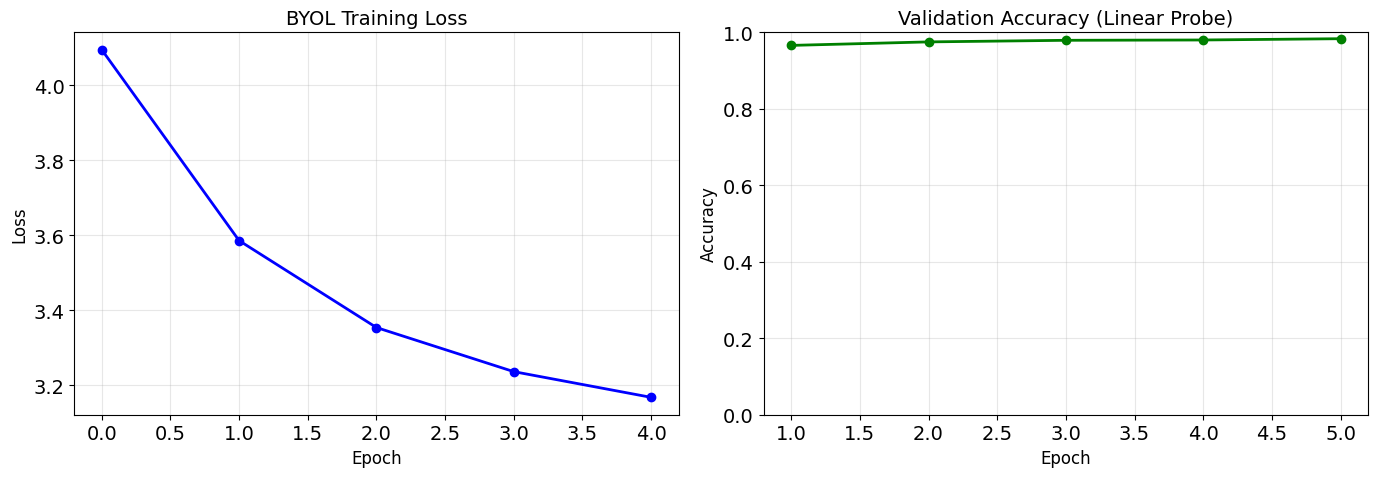

Best validation accuracy: 0.9833
Final validation accuracy: 0.9833
Final training loss: 3.1674


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, linewidth=2, color='blue', marker='o')
axes[0].set_title('BYOL Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(val_accuracies) + 1), val_accuracies,
             marker='o', linestyle='-', linewidth=2, color='green', markersize=6)
axes[1].set_title('Validation Accuracy (Linear Probe)', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(val_accuracies):.4f}")
print(f"Final validation accuracy: {val_accuracies[-1]:.4f}")
print(f"Final training loss: {train_losses[-1]:.4f}")


Слушайте, так то супер работает!! Высокая акураси уже сразу у нас, лосс стабильно падает, думаю на большем количестве эпох мы бы и получше качество смогли выбить. В целом можно сказать, что BYOL молодец! Хоть и не догнал супервайзд, но вот InfoNCE превзошел

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

Что ж, сделаем

In [ ]:
def evaluate_supervised_direct(model, val_loader):
    """Прямая оценка supervised модели"""
    model.eval()
    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128).to(device)

    correct = 0
    total = 0

    with torch.no_grad():
        for audio, labels in val_loader:
            audio = audio.unsqueeze(1).to(device)
            labels = labels.to(device)
            spectrograms = mel_transform(audio.squeeze(1))
            spectrograms = spectrograms.unsqueeze(1)

            outputs = model(spectrograms)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

def evaluate_contrastive_embeddings(model, val_loader, config, combine='concat'):
    """Оценка контрастивной модели (InfoNCE)"""
    model.eval()
    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128).to(device)

    all_features = []
    all_labels = []

    with torch.no_grad():
        for audio, labels in val_loader:
            audio = audio.to(device)
            spectrograms, waveforms = create_contrastive_input(audio, mel_transform, augmentation=False)

            _, _, feat_1d, feat_2d = model(waveforms, spectrograms)

            if combine == '1d_only':
                features = feat_1d
            elif combine == '2d_only':
                features = feat_2d
            else:  #конкат
                features = torch.cat([feat_1d, feat_2d], dim=1)

            all_features.append(features.cpu())
            all_labels.append(labels)

    features = torch.cat(all_features, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    features = np.nan_to_num(features, nan=0.0)

    X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42)

    clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
    clf.fit(X_train, y_train)
    return clf.score(X_val, y_val)

def evaluate_byol_embeddings(model, val_loader, config, combine='concat'):
    """Оценка BYOL"""
    model.eval()
    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128).to(device)

    all_features = []
    all_labels = []

    with torch.no_grad():
        for audio, labels in val_loader:
            audio = audio.to(device)
            (spec, wav), _ = create_byol_input(audio, mel_transform, augmentation=False)

            feat_1d = model.online_encoder_1d(wav)
            feat_2d = model.online_encoder_2d(spec)

            if combine == '1d_only':
                features = feat_1d
            elif combine == '2d_only':
                features = feat_2d
            else:  #конкат
                features = torch.cat([feat_1d, feat_2d], dim=1)

            all_features.append(features.cpu())
            all_labels.append(labels)

    features = torch.cat(all_features, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    features = np.nan_to_num(features, nan=0.0)

    X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42)

    clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
    clf.fit(X_train, y_train)
    return clf.score(X_val, y_val)




results = {}
try:
    supervised_acc = evaluate_supervised_direct(supervised_model, val_loader)
    results['Supervised (baseline)'] = supervised_acc
    print(f"   Supervised accuracy: {supervised_acc:.4f}")
except Exception as e:
    results['Supervised (baseline)'] = 0.0
try:
    results['InfoNCE (1D encoder)'] = evaluate_contrastive_embeddings(contrastive_model, val_loader, contrastive_config, combine='1d_only')
    print(f"   InfoNCE 1D only: {results['InfoNCE (1D encoder)']:.4f}")
except Exception as e:
    results['InfoNCE (1D encoder)'] = 0.0
try:
    results['InfoNCE (2D encoder)'] = evaluate_contrastive_embeddings(contrastive_model, val_loader, contrastive_config, combine='2d_only')
    print(f"   InfoNCE 2D only: {results['InfoNCE (2D encoder)']:.4f}")
except Exception as e:
    results['InfoNCE (2D encoder)'] = 0.0
try:
    results['InfoNCE (concat)'] = evaluate_contrastive_embeddings(contrastive_model, val_loader, contrastive_config, combine='concat')
    print(f"   InfoNCE concat: {results['InfoNCE (concat)']:.4f}")
except Exception as e:
    results['InfoNCE (concat)'] = 0.0
try:
    results['BYOL (1D encoder)'] = evaluate_byol_embeddings(byol_model, val_loader, byol_config, combine='1d_only')
    print(f"   BYOL 1D only: {results['BYOL (1D encoder)']:.4f}")
except Exception as e:
    results['BYOL (1D encoder)'] = 0.0
try:
    results['BYOL (2D encoder)'] = evaluate_byol_embeddings(byol_model, val_loader, byol_config, combine='2d_only')
    print(f"   BYOL 2D only: {results['BYOL (2D encoder)']:.4f}")
except Exception as e:
    results['BYOL (2D encoder)'] = 0.0
try:
    results['BYOL (concat)'] = evaluate_byol_embeddings(byol_model, val_loader, byol_config, combine='concat')
    print(f"   BYOL concat: {results['BYOL (concat)']:.4f}")
except Exception as e:
    results['BYOL (concat)'] = 0.0

   Supervised accuracy: 0.9908
   InfoNCE 1D only: 0.9250
   InfoNCE 2D only: 0.9467
   InfoNCE concat: 0.9667
   BYOL 1D only: 0.9317
   BYOL 2D only: 0.9808
   BYOL concat: 0.9800


**Выводы** (о боже неужели):

Самая лучшая моделька - **Supervised**. Неожиданно - нет :) В целом я уже на 3 эпохе его обучения поняла, что он гений (тот самый программист гугла в 7 лет). Ну вообще качество у него самое высокое (99.67%) и это объяснимо - он обучается прямо на целевой задаче и использует размеченные примеры.

Из интересного - классное качество у BYOL concat, то есть конкатенация эмбеддингов дает дополнительный буст к качеству, все еще не супервайзд, но уже довольно близко, прямо дышим ему в спину. То есть у нас 1Д и 2Д энкодеры выучитывают разные признаки и при конкатенации они друг друга дополняют, а значит мы имеем более полное представление об аудио, что несомненно круто. Для InfoNCE наблюдение аналогичное

Если говорить про  BYOL и InfoNCE, то BYOL оказался круче. Полагаю, что BYOL учит модель предсказывать представления другой аугментации, что заставляет модель как бы понимать "сущность" звука, а не просто различать разные аудио

Вывод всех выводов - **BYOL самый крутой self-supervised** метод для данной задачи!!! Он почти догнал супервайзд, краш
